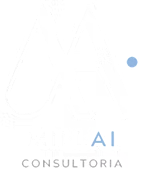

# Klike Data Science Challenge - Millai

**Autor:** Carlos Vitor Freitas Santos  

---

## Contexto de Negócio

A Millai é uma consultoria especializada na intersecção entre Marketing e Inteligência Artificial. Seu principal produto, o **Klike**, é uma plataforma inovadora que utiliza IA para analisar anúncios em vídeo. O Klike pontua os criativos, identifica oportunidades de melhoria e apoia os times de marketing na tomada de decisões estratégicas.

Neste projeto, trabalharemos com um dataset contendo 500 registros de campanhas de vídeo veiculadas em diferentes plataformas (como Meta, TikTok e LinkedIn). O objetivo principal é entender e prever o **Klike Score** (`klike_score`), uma pontuação de 0 a 100 gerada pela IA que representa a qualidade geral de um criativo.

## Objetivos da Análise

Este notebook foi estruturado para resolver o desafio técnico seguindo um pipeline lógico de Ciência de Dados, focado em pragmatismo e geração de valor:

1. **Análise Exploratória de Dados (EDA):** Investigar o comportamento das métricas, distribuições e identificar quais características do vídeo (como duração, formato e presença de rosto humano) mais se correlacionam com um alto desempenho.
2. **Modelagem Preditiva:** Construir e avaliar um modelo capaz de prever o `klike_score` com base nos atributos do criativo.
3. **Motor de Recomendações (Insights):** Traduzir os resultados do modelo em recomendações acionáveis, quantificadas e contextualizadas para otimizar futuras campanhas.

---

## Dicionário de Dados

Abaixo estão os detalhes de cada atributo presente no dataset simulado, abrangendo características do criativo e métricas de performance:

| Coluna | Descrição |
| :--- | :--- |
| `campaign_id` | Identificador único da campanha |
| `date` | Data de veiculação |
| `platform` | Plataforma (Meta, Tik Tok, LinkedIn) |
| `category` | Categoria do anunciante (E-commerce, SaaS, App Install, Branding, Lead Gen) |
| `objective` | Objetivo da campanha (awareness, traffic, conversions, engagement, app_install) |
| `target_audience_age`| Faixa etária do público-alvo (18-24, 25-34, 35-44, 45+) |
| `is_retargeting` | Se a campanha é de retargeting (True) ou prospecção (False) |
| `video_duration_s` | Duração do vídeo em segundos |
| `format` | Formato do vídeo (vertical, horizontal, quadrado) |
| `has_subtitle` | Se o vídeo possui legendas |
| `has_cta` | Se o vídeo possui call-to-action |
| `has_hook` | Se o vídeo possui hook nos primeiros 3 segundos |
| `has_face` | Se o vídeo apresenta rosto humano |
| `text_density` | Quantidade de texto on-screen (low, medium, high) |
| `music_voice_ratio` | Proporção música/voz (0 = só voz, 1 = só música) |
| `impressions` | Número de impressões |
| `clicks` | Número de cliques |
| `ctr` | Click-through rate |
| `cpc` | Custo por clique (R$) |
| `spend` | Gasto total (R$) |
| `conversions` | Número de conversões |
| `revenue` | Receita gerada (R$) |
| `roas` | Return on Ad Spend |
| `avg_watch_time_s` | Tempo médio de visualização do vídeo (segundos) |
| `engagement_rate` | Taxa de engajamento (likes + comentários + compartilhamentos / impressões) |
| **`klike_score`** | **Score de qualidade do criativo (0-100) — Variável Target** |

---

## *1. Importação de bibliotecas e configuração do ambiente*

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker


pd.set_option("display.max_columns", None)

## *2. Dataset*

In [80]:
df = pd.read_csv("./data/klike_challenge_dataset.csv")

df.head()

,campaign_id,date,platform,category,objective,target_audience_age,is_retargeting,video_duration_s,format,has_subtitle,has_cta,has_hook,has_face,text_density,music_voice_ratio,impressions,clicks,ctr,cpc,spend,conversions,revenue,roas,avg_watch_time_s,engagement_rate,klike_score
0,KLK-0001,2024-01-01,Meta,Branding,awareness,18-24,False,NaN,vertical,True,True,False,True,medium,0.39,150825,5882,0.0390,0.82,4823.24,48,0.00,0.00,3.9,0.0446,63.6
1,KLK-0002,2024-03-22,LinkedIn,App Install,traffic,25-34,False,NaN,horizontal,True,True,True,True,low,0.07,7433,493,0.0664,3.54,1745.22,34,NaN,0.16,6.4,0.0217,70.0
2,KLK-0003,2024-05-04,TikTok,SaaS,traffic,25-34,False,8.0,vertical,True,True,True,True,medium,0.43,193198,15069,0.0780,0.38,5726.22,492,51053.44,8.92,8.0,0.1000,99.1
3,KLK-0004,2024-12-27,TikTok,Lead Gen,engagement,25-34,False,27.0,quadrado,False,True,True,True,medium,0.54,6506,601,0.0925,0.71,426.71,19,1113.78,2.61,20.3,0.0414,74.9
4,KLK-0005,2024-07-10,Meta,Branding,engagement,25-34,False,34.0,vertical,True,True,True,True,low,0.35,63830,2355,0.0369,0.38,894.90,13,0.00,0.00,34.0,0.0184,77.9


In [81]:
df.tail()

,campaign_id,date,platform,category,objective,target_audience_age,is_retargeting,video_duration_s,format,has_subtitle,has_cta,has_hook,has_face,text_density,music_voice_ratio,impressions,clicks,ctr,cpc,spend,conversions,revenue,roas,avg_watch_time_s,engagement_rate,klike_score
495,KLK-0496,2024-08-04,Meta,E-commerce,traffic,25-34,True,6.0,vertical,False,False,True,True,medium,NaN,5004,78,0.0156,0.69,53.82,6,374.42,6.96,3.2,0.0216,64.1
496,KLK-0497,2024-02-24,TikTok,Lead Gen,engagement,18-24,True,NaN,vertical,False,True,True,False,medium,0.53,21026,3153,0.1500,0.31,977.43,213,12977.47,13.28,7.7,0.0221,76.5
497,KLK-0498,2024-05-25,Meta,E-commerce,conversions,25-34,True,27.0,horizontal,True,False,True,True,low,0.16,148427,15852,0.1068,0.64,10145.28,748,17251.49,1.70,18.2,NaN,69.7
498,KLK-0499,2024-11-26,LinkedIn,Lead Gen,engagement,45+,False,16.0,quadrado,True,False,False,True,medium,0.66,16239,112,0.0069,2.10,235.20,5,314.83,1.34,5.1,0.0289,41.8
499,KLK-0500,2024-12-30,LinkedIn,SaaS,conversions,25-34,False,28.0,horizontal,True,False,True,False,high,0.05,68133,8203,0.1204,1.78,14601.34,120,13814.24,0.95,17.5,0.0016,55.4


In [82]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   campaign_id          500 non-null    str    
 1   date                 500 non-null    str    
 2   platform             500 non-null    str    
 3   category             500 non-null    str    
 4   objective            500 non-null    str    
 5   target_audience_age  500 non-null    str    
 6   is_retargeting       500 non-null    bool   
 7   video_duration_s     461 non-null    float64
 8   format               500 non-null    str    
 9   has_subtitle         454 non-null    object 
 10  has_cta              500 non-null    bool   
 11  has_hook             500 non-null    bool   
 12  has_face             500 non-null    bool   
 13  text_density         500 non-null    str    
 14  music_voice_ratio    462 non-null    float64
 15  impressions          500 non-null    int64  
 16  c

In [83]:
df.shape

(500, 26)

In [84]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
video_duration_s,461.0,19.392625,1.352935e+01,5.0000,11.0000,16.00000,25.0000,115.00
music_voice_ratio,462.0,0.399848,2.026735e-01,0.0200,0.2300,0.38500,0.5500,0.92
impressions,500.0,153738.524000,1.171736e+06,1000.0000,9986.0000,23241.00000,55172.7500,14052761.00
clicks,500.0,3594.104000,7.018213e+03,4.0000,461.7500,1351.00000,3583.2500,72545.00
ctr,500.0,0.070968,4.530216e-02,0.0022,0.0332,0.06275,0.1048,0.15
cpc,472.0,1.112903,1.955625e+00,0.0500,0.5300,0.71000,1.0200,26.05
spend,500.0,4213.151620,1.157398e+04,2.9600,313.4525,1031.00000,2867.9525,121226.10
conversions,500.0,131.352000,3.145654e+02,0.0000,10.0000,34.50000,111.0000,3666.00
revenue,475.0,6367.936863,1.926718e+04,0.0000,262.1750,1201.05000,4189.0250,241597.29
roas,500.0,2.499000,3.592365e+00,0.0000,0.4300,1.49000,3.2500,39.92


In [85]:
df.describe(include=['object', 'string'])

,campaign_id,date,platform,category,objective,target_audience_age,format,has_subtitle,text_density
count,500,500,500,500,500,500,500,454,500
unique,500,273,3,5,5,4,3,2,3
top,KLK-0001,2024-06-27,Meta,E-commerce,conversions,25-34,vertical,True,medium
freq,1,6,241,165,165,143,269,263,230


In [86]:
df.isnull().sum()

campaign_id             0
date                    0
platform                0
category                0
objective               0
target_audience_age     0
is_retargeting          0
video_duration_s       39
format                  0
has_subtitle           46
has_cta                 0
has_hook                0
has_face                0
text_density            0
music_voice_ratio      38
impressions             0
clicks                  0
ctr                     0
cpc                    28
spend                   0
conversions             0
revenue                25
roas                    0
avg_watch_time_s       27
engagement_rate        32
klike_score             0
dtype: int64

In [87]:
df.duplicated().sum()

np.int64(0)

In [88]:
df.dtypes

campaign_id                str
date                       str
platform                   str
category                   str
objective                  str
target_audience_age        str
is_retargeting            bool
video_duration_s       float64
format                     str
has_subtitle            object
has_cta                   bool
has_hook                  bool
has_face                  bool
text_density               str
music_voice_ratio      float64
impressions              int64
clicks                   int64
ctr                    float64
cpc                    float64
spend                  float64
conversions              int64
revenue                float64
roas                   float64
avg_watch_time_s       float64
engagement_rate        float64
klike_score            float64
dtype: object

In [89]:
string_columns = df.select_dtypes(include=['object', "string"]).columns


for column in string_columns:
    print(f"Valores únicos da coluna '{column}':")
    print(df[column].unique())
    print()


Valores únicos da coluna 'campaign_id':
<ArrowStringArray>
['KLK-0001', 'KLK-0002', 'KLK-0003', 'KLK-0004', 'KLK-0005', 'KLK-0006',
 'KLK-0007', 'KLK-0008', 'KLK-0009', 'KLK-0010',
 ...
 'KLK-0491', 'KLK-0492', 'KLK-0493', 'KLK-0494', 'KLK-0495', 'KLK-0496',
 'KLK-0497', 'KLK-0498', 'KLK-0499', 'KLK-0500']
Length: 500, dtype: str

Valores únicos da coluna 'date':
<ArrowStringArray>
['2024-01-01', '2024-03-22', '2024-05-04', '2024-12-27', '2024-07-10',
 '2024-03-15', '2024-05-02', '2024-04-30', '2024-01-08', '2024-02-19',
 ...
 '2024-10-07', '2024-06-09', '2024-05-24', '2024-12-21', '2024-01-03',
 '2024-11-24', '2024-08-26', '2024-03-21', '2024-08-04', '2024-11-26']
Length: 273, dtype: str

Valores únicos da coluna 'platform':
<ArrowStringArray>
['Meta', 'LinkedIn', 'TikTok']
Length: 3, dtype: str

Valores únicos da coluna 'category':
<ArrowStringArray>
['Branding', 'App Install', 'SaaS', 'Lead Gen', 'E-commerce']
Length: 5, dtype: str

Valores únicos da coluna 'objective':
<ArrowString

In [90]:
df[df["video_duration_s"].isnull()].head()

,campaign_id,date,platform,category,objective,target_audience_age,is_retargeting,video_duration_s,format,has_subtitle,has_cta,has_hook,has_face,text_density,music_voice_ratio,impressions,clicks,ctr,cpc,spend,conversions,revenue,roas,avg_watch_time_s,engagement_rate,klike_score
0,KLK-0001,2024-01-01,Meta,Branding,awareness,18-24,False,NaN,vertical,True,True,False,True,medium,0.39,150825,5882,0.0390,0.82,4823.24,48,0.00,0.00,3.9,0.0446,63.6
1,KLK-0002,2024-03-22,LinkedIn,App Install,traffic,25-34,False,NaN,horizontal,True,True,True,True,low,0.07,7433,493,0.0664,3.54,1745.22,34,NaN,0.16,6.4,0.0217,70.0
6,KLK-0007,2024-05-02,Meta,Lead Gen,engagement,18-24,False,NaN,quadrado,True,False,False,True,medium,0.33,12960,1877,0.1449,NaN,2158.55,37,2233.56,1.03,11.9,0.0530,64.9
21,KLK-0022,2024-02-10,Meta,SaaS,awareness,18-24,False,NaN,quadrado,True,True,False,True,low,0.35,334928,17617,0.0526,0.97,17088.49,516,50672.50,2.97,6.8,NaN,71.5
39,KLK-0040,2024-10-20,Meta,E-commerce,conversions,45+,False,NaN,quadrado,False,True,True,True,high,0.67,117901,2747,0.0233,0.91,2499.77,106,3040.24,1.22,11.3,0.0247,47.9


In [91]:
df_copy = df.copy()

In [92]:
percentage_video_duration_s = df[df["video_duration_s"].isnull()].shape[0]/df.shape[0]

percentage_video_duration_s

0.078

### Tratamento de Valores Nulos: `video_duration_s`

Identificamos 39 valores nulos na variável `video_duration_s` (aprox. 7.8% do dataset). Como temos um volume de dados pequeno (500 linhas), excluir esses registros resultaria em perda de informação.

**Estratégia adotada:** Preenchimento com a mediana agrupada por plataforma (`platform`). 
**Justificativa:** O comportamento de consumo e as regras das plataformas variam muito. Vídeos no TikTok tendem a ser mais curtos, enquanto o LinkedIn pode suportar conteúdos mais longos. Usar a mediana por plataforma respeita a distribuição natural de cada canal e evita o viés de *outliers*.

In [93]:

df.groupby('platform')['video_duration_s'].median()

platform
LinkedIn    24.5
Meta        16.0
TikTok      13.0
Name: video_duration_s, dtype: float64

In [94]:
df['video_duration_s'] = df['video_duration_s'].fillna(
    df.groupby('platform')['video_duration_s'].transform('median')
)

In [95]:

df['video_duration_s'].isnull().sum()

np.int64(0)

### Tratamento de Valores Nulos: `has_subtitle`

A coluna `has_subtitle` possui 46 valores nulos (aprox. 9.2%). Como se trata de uma variável booleana (True/False), a estratégia de imputação precisa fazer sentido do ponto de vista do formato do anúncio.

**Estratégia adotada:** Preenchimento com o valor mais frequente (Moda) agrupado por plataforma (`platform`).
**Justificativa:** O uso de legendas é fortemente ditado pela cultura de consumo de cada plataforma. Por exemplo, vídeos no TikTok ou Meta (Reels/Stories) frequentemente utilizam legendas para reter a atenção em visualizações sem som, enquanto outras plataformas podem ter comportamentos distintos. Preencher com a moda de cada canal preserva essa tendência comportamental.

*(Nota analítica: Outra variável interessante que apoia o contexto de legendas é a `music_voice_ratio`. Vídeos exclusivamente musicais teriam, logicamente, menos necessidade de legendas de fala).*

In [96]:
percentage_has_subtitle = df[df["has_subtitle"].isnull()].shape[0]/df.shape[0]

percentage_has_subtitle

0.092

In [97]:
df.groupby('platform')['has_subtitle'].value_counts(dropna=False)

platform  has_subtitle
LinkedIn  True             45
          False            29
          NaN               9
Meta      True            128
          False            92
          NaN              21
TikTok    True             90
          False            70
          NaN              16
Name: count, dtype: int64

In [98]:
def fill_with_mode(series):
    mode_val = series.mode()
    if not mode_val.empty:
        return series.fillna(mode_val[0])
    return series

In [99]:
df['has_subtitle'] = df.groupby('platform')['has_subtitle'].transform(fill_with_mode)

In [100]:
df['has_subtitle'].isnull().sum()

np.int64(0)

### Tratamento de Valores Nulos: `music_voice_ratio`

A variável `music_voice_ratio` possui 38 valores ausentes. Ela representa a proporção de áudio, onde 0 é exclusivamente voz e 1 é exclusivamente música. 

**Estratégia adotada:** Preenchimento com a mediana agrupada por Plataforma (`platform`) e Categoria do Anunciante (`category`).
**Justificativa Analítica:** A assinatura sonora de um criativo é fortemente influenciada por onde ele é veiculado e o que ele vende. Por exemplo, campanhas de empresas SaaS no LinkedIn tendem a ter uma abordagem mais explicativa (maior predominância de voz), enquanto campanhas de App Install no TikTok costumam focar em estímulos visuais rápidos com trilhas sonoras em alta (maior predominância de música). O agrupamento duplo garante que a imputação respeite o nicho específico da campanha.

In [101]:
percentage_music_voice_ratio = df[df["music_voice_ratio"].isnull()].shape[0]/df.shape[0]

percentage_music_voice_ratio

0.076

In [102]:
df.groupby(['platform', 'category'])['music_voice_ratio'].median()

platform  category   
LinkedIn  App Install    0.330
          Branding       0.480
          E-commerce     0.380
          Lead Gen       0.320
          SaaS           0.320
Meta      App Install    0.470
          Branding       0.390
          E-commerce     0.370
          Lead Gen       0.410
          SaaS           0.365
TikTok    App Install    0.380
          Branding       0.420
          E-commerce     0.390
          Lead Gen       0.460
          SaaS           0.380
Name: music_voice_ratio, dtype: float64

In [103]:
df['music_voice_ratio'] = df['music_voice_ratio'].fillna(
    df.groupby(['platform', 'category'])['music_voice_ratio'].transform('median')
)

In [104]:
df['music_voice_ratio'].isnull().sum()

np.int64(0)

### Tratamento de Valores Nulos: `cpc` (Custo por Clique)

A coluna `cpc` apresenta 28 valores nulos. Diferente de variáveis comportamentais, o CPC é uma métrica determinística de marketing, calculada pela razão entre o investimento total e o volume de cliques gerados.

**Estratégia adotada:** Cálculo exato a partir das colunas base ($CPC = Spend / Clicks$).
**Justificativa Analítica:** Como não temos valores nulos nas colunas `spend` (Gasto) e `clicks` (Cliques), a imputação estatística (como média ou mediana) introduziria um erro matemático no dataset. A melhor abordagem é reconstruir o dado real aplicando a fórmula oficial da métrica, garantindo também o tratamento seguro para divisões por zero (campanhas sem cliques).

In [105]:
percentage_cpc = df[df["cpc"].isnull()].shape[0]/df.shape[0]

percentage_cpc

0.056

In [106]:
df['cpc'] = df['cpc'].fillna(df['spend'] / df['clicks'])

df['cpc'] = df['cpc'].replace([np.inf, -np.inf], 0)

df['cpc'] = df['cpc'].round(2)

In [107]:
df['cpc'].isnull().sum()

np.int64(0)

### Tratamento de Valores Nulos: `revenue` (Receita Gerada)

A coluna `revenue` apresenta 25 valores ausentes. Assim como o custo por clique, a receita em campanhas de marketing pode ser derivada de forma determinística caso tenhamos as métricas de Gasto (`spend`) e Retorno sobre o Gasto (`roas`).

**Estratégia adotada:** Cálculo exato a partir das colunas base ($Revenue = ROAS \times Spend$).
**Justificativa Analítica:** A utilização de preenchimento estatístico (média/mediana) para métricas financeiras corromperia a integridade matemática da base de dados. Como as colunas `spend` e `roas` não possuem valores nulos, a melhor abordagem é recalcular a receita real reconstruindo o dado através da fórmula padrão de performance de anúncios.

In [108]:

df['revenue'] = df['revenue'].fillna(df['roas'] * df['spend'])

df['revenue'] = df['revenue'].round(2)

In [109]:
df['revenue'].isnull().sum()

np.int64(0)

### Tratamento de Valores Nulos: `avg_watch_time_s`

A variável `avg_watch_time_s` (tempo médio de visualização) possui 27 valores nulos. Preencher esses dados com médias ou medianas absolutas apresenta um grande risco de inconsistência lógica: poderíamos acidentalmente imputar um tempo de visualização maior do que a duração total do próprio vídeo (`video_duration_s`).

**Estratégia adotada:** Imputação baseada na Taxa de Retenção (*Completion Rate*) mediana por plataforma.
**Justificativa Analítica:** A proporção de um vídeo que o usuário assiste varia fortemente de acordo com a plataforma (ex: consumo rápido no TikTok vs. consumo mais longo no LinkedIn). Primeiro, criamos uma métrica temporária de taxa de retenção (Tempo Assistido / Duração do Vídeo). Em seguida, calculamos a mediana dessa taxa para cada plataforma. Finalmente, preenchemos os nulos multiplicando a duração do vídeo em questão por essa taxa de retenção esperada, garantindo total coerência matemática.

In [110]:
df['temp_completion_rate'] = df['avg_watch_time_s'] / df['video_duration_s']

median_rate_by_platform = df.groupby('platform')['temp_completion_rate'].transform('median')

df['avg_watch_time_s'] = df['avg_watch_time_s'].fillna(df['video_duration_s'] * median_rate_by_platform)

df['avg_watch_time_s'] = df['avg_watch_time_s'].round(1)
df = df.drop(columns=['temp_completion_rate'])

In [111]:
df['avg_watch_time_s'].isnull().sum()

np.int64(0)

In [112]:
df.isnull().sum()

campaign_id             0
date                    0
platform                0
category                0
objective               0
target_audience_age     0
is_retargeting          0
video_duration_s        0
format                  0
has_subtitle            0
has_cta                 0
has_hook                0
has_face                0
text_density            0
music_voice_ratio       0
impressions             0
clicks                  0
ctr                     0
cpc                     0
spend                   0
conversions             0
revenue                 0
roas                    0
avg_watch_time_s        0
engagement_rate        32
klike_score             0
dtype: int64

### Tratamento de Valores Nulos: `engagement_rate`

A coluna `engagement_rate` apresenta 32 valores ausentes. [cite_start]Segundo o dicionário de dados, essa métrica é a razão entre interações (likes, comentários, compartilhamentos) e impressões. Como não possuímos as variáveis absolutas de interação no dataset para um cálculo determinístico, optamos por uma imputação estatística contextualizada.

**Estratégia adotada:** Preenchimento com a mediana agrupada por Plataforma (`platform`) e Objetivo da Campanha (`objective`).
**Justificativa Analítica:** A propensão de um usuário interagir com um anúncio depende fortemente da cultura da rede social (plataforma) e da chamada para ação principal. Campanhas com objetivo de `engagement` ou `awareness` costumam reter o usuário na própria plataforma gerando curtidas, enquanto campanhas de `traffic` ou `conversions` focam em tirar o usuário da rede, o que muitas vezes diminui as interações diretas no post. Agrupar por essas duas dimensões garante uma estimativa altamente realista.

In [113]:
df['engagement_rate'] = df['engagement_rate'].fillna(
    df.groupby(['platform', 'objective'])['engagement_rate'].transform('median')
)

df['engagement_rate'] = df['engagement_rate'].fillna(
    df.groupby('platform')['engagement_rate'].transform('median')
)


In [114]:
df['engagement_rate'].isnull().sum()

np.int64(0)

In [115]:
df.isnull().sum()

campaign_id            0
date                   0
platform               0
category               0
objective              0
target_audience_age    0
is_retargeting         0
video_duration_s       0
format                 0
has_subtitle           0
has_cta                0
has_hook               0
has_face               0
text_density           0
music_voice_ratio      0
impressions            0
clicks                 0
ctr                    0
cpc                    0
spend                  0
conversions            0
revenue                0
roas                   0
avg_watch_time_s       0
engagement_rate        0
klike_score            0
dtype: int64

### Validação do Tratamento de Dados (Sanity Check)

Para garantir a integridade da nossa base de dados após o tratamento dos valores ausentes, vamos comparar o dataset original (`df_copy`) com o dataset limpo (`df`). 

O objetivo desta etapa é duplo:
1. **Verificação Qualitativa:** Confirmar que não restam valores nulos nas colunas tratadas.
2. **Verificação Quantitativa (Distribuição):** Garantir que as estratégias de imputação (como mediana agrupada e cálculo exato) preservaram a variância e a distribuição natural das variáveis, evitando a introdução de vieses no modelo preditivo que construiremos a seguir.

In [116]:
null_comparison = pd.DataFrame({
    'Nulos Antes (df_copy)': df_copy.isnull().sum(),
    'Nulos Depois (df)': df.isnull().sum()
})

null_comparison.head()

,Nulos Antes (df_copy),Nulos Depois (df)
campaign_id,0,0
date,0,0
platform,0,0
category,0,0
objective,0,0


In [117]:
columns_with_nulls = null_comparison[null_comparison['Nulos Antes (df_copy)'] > 0]
columns_with_nulls

,Nulos Antes (df_copy),Nulos Depois (df)
video_duration_s,39,0
has_subtitle,46,0
music_voice_ratio,38,0
cpc,28,0
revenue,25,0
avg_watch_time_s,27,0
engagement_rate,32,0


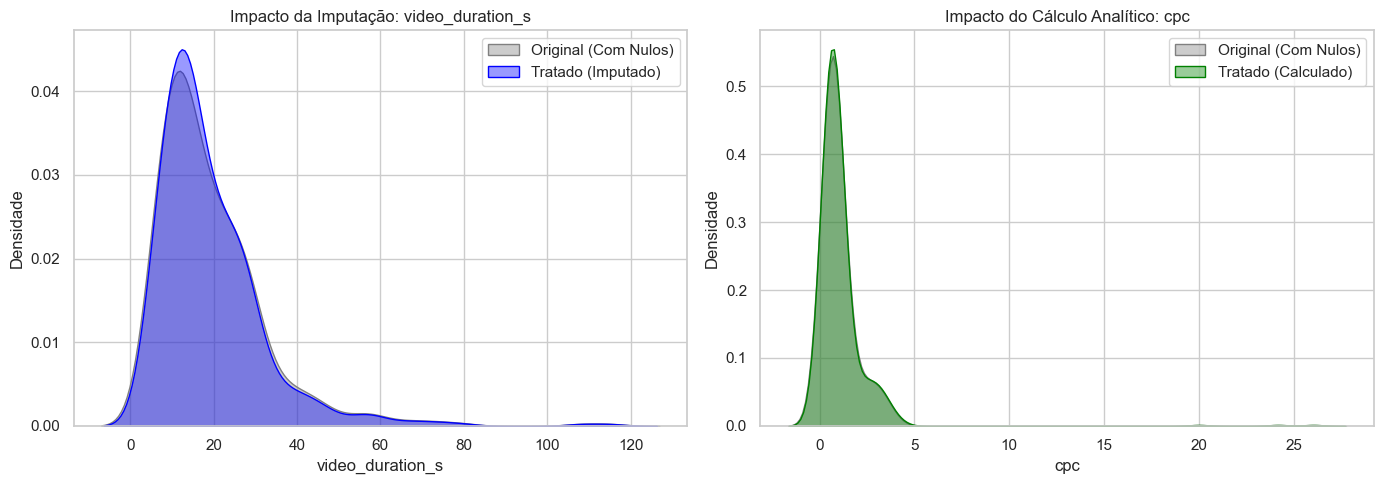

In [118]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(data=df_copy, x='video_duration_s', label='Original (Com Nulos)', ax=axes[0], fill=True, alpha=0.4, color='gray')
sns.kdeplot(data=df, x='video_duration_s', label='Tratado (Imputado)', ax=axes[0], fill=True, alpha=0.4, color='blue')
axes[0].set_title('Impacto da Imputação: video_duration_s', fontsize=12)
axes[0].set_ylabel('Densidade')
axes[0].legend()

sns.kdeplot(data=df_copy, x='cpc', label='Original (Com Nulos)', ax=axes[1], fill=True, alpha=0.4, color='gray')
sns.kdeplot(data=df, x='cpc', label='Tratado (Calculado)', ax=axes[1], fill=True, alpha=0.4, color='green')
axes[1].set_title('Impacto do Cálculo Analítico: cpc', fontsize=12)
axes[1].set_ylabel('Densidade')
axes[1].legend()

plt.tight_layout()
plt.show()

### Tratamento da Variável Identificadora (`campaign_id`)

A coluna `campaign_id` atua como a chave primária (identificador único) de cada registro. Como ela possui cardinalidade máxima (500 valores únicos para 500 linhas) e não carrega nenhuma variância ou sinal preditivo de negócio, mantê-la como uma *feature* comum pode gerar ruído nas análises estatísticas e causar *overfitting* nos modelos de Machine Learning.

**Estratégia adotada:** Transformar a coluna no Índice (Index) do DataFrame.
**Justificativa:** Isso remove a coluna do escopo analítico e preditivo, mas preserva o rótulo da campanha, o que será fundamental para a identificação dos registros na construção do Sistema de Recomendações (Parte 3 do desafio).

In [119]:
df = df.set_index('campaign_id')

df.index.name = None

In [120]:
df.head()

,date,platform,category,objective,target_audience_age,is_retargeting,video_duration_s,format,has_subtitle,has_cta,has_hook,has_face,text_density,music_voice_ratio,impressions,clicks,ctr,cpc,spend,conversions,revenue,roas,avg_watch_time_s,engagement_rate,klike_score
KLK-0001,2024-01-01,Meta,Branding,awareness,18-24,False,16.0,vertical,True,True,False,True,medium,0.39,150825,5882,0.0390,0.82,4823.24,48,0.00,0.00,3.9,0.0446,63.6
KLK-0002,2024-03-22,LinkedIn,App Install,traffic,25-34,False,24.5,horizontal,True,True,True,True,low,0.07,7433,493,0.0664,3.54,1745.22,34,279.24,0.16,6.4,0.0217,70.0
KLK-0003,2024-05-04,TikTok,SaaS,traffic,25-34,False,8.0,vertical,True,True,True,True,medium,0.43,193198,15069,0.0780,0.38,5726.22,492,51053.44,8.92,8.0,0.1000,99.1
KLK-0004,2024-12-27,TikTok,Lead Gen,engagement,25-34,False,27.0,quadrado,False,True,True,True,medium,0.54,6506,601,0.0925,0.71,426.71,19,1113.78,2.61,20.3,0.0414,74.9
KLK-0005,2024-07-10,Meta,Branding,engagement,25-34,False,34.0,vertical,True,True,True,True,low,0.35,63830,2355,0.0369,0.38,894.90,13,0.00,0.00,34.0,0.0184,77.9


### Feature Engineering: Variável Temporal (`date`)

A coluna `date` original está em formato de texto (string) e não pode ser processada diretamente por algoritmos de Machine Learning. Além disso, datas absolutas carregam menos poder preditivo do que os padrões cíclicos que elas representam.

**Estratégia adotada:** Conversão para `datetime` e extração de novas *features* temporais.
**Justificativa Analítica:** No ecossistema de anúncios de vídeo (Klike), o comportamento da audiência é altamente sazonal e dependente do dia da semana. Para capturar esses padrões, extraímos o **mês** (para sazonalidade de médio prazo) e o **dia da semana**. Além disso, criamos uma nova variável binária, `is_weekend` (Fim de Semana), assumindo a premissa de que o engajamento e as taxas de conversão variam significativamente entre dias úteis e finais de semana. Após a extração, a coluna original será removida.

In [121]:
df['date'] = pd.to_datetime(df['date'])

df['month'] = df['date'].dt.month

df['day_of_week'] = df['date'].dt.dayofweek

df['is_weekend'] = (df['date'].dt.dayofweek >= 5).astype(int)


In [122]:
df = df.drop(columns=['date'])

In [123]:
df[['month', 'day_of_week', 'is_weekend']].head()

,month,day_of_week,is_weekend
KLK-0001,1,0,0
KLK-0002,3,4,0
KLK-0003,5,5,1
KLK-0004,12,4,0
KLK-0005,7,2,0


In [124]:
print(df.head(2))

          platform     category  objective target_audience_age  \
KLK-0001      Meta     Branding  awareness               18-24   
KLK-0002  LinkedIn  App Install    traffic               25-34   

          is_retargeting  video_duration_s      format has_subtitle  has_cta  \
KLK-0001           False              16.0    vertical         True     True   
KLK-0002           False              24.5  horizontal         True     True   

          has_hook  has_face text_density  music_voice_ratio  impressions  \
KLK-0001     False      True       medium               0.39       150825   
KLK-0002      True      True          low               0.07         7433   

          clicks     ctr   cpc    spend  conversions  revenue  roas  \
KLK-0001    5882  0.0390  0.82  4823.24           48     0.00  0.00   
KLK-0002     493  0.0664  3.54  1745.22           34   279.24  0.16   

          avg_watch_time_s  engagement_rate  klike_score  month  day_of_week  \
KLK-0001               3.9        

### Análise de Outliers (Valores Atípicos)

Nesta etapa, vamos investigar a presença de outliers nas nossas variáveis numéricas contínuas. 
No contexto de marketing digital, é crucial ter cuidado ao tratar outliers: um vídeo com um número de visualizações (impressions) ou conversões absurdamente alto pode não ser um erro de dados, mas sim um **criativo viral** (um caso de sucesso extremo). Portanto, nossa abordagem aqui será primariamente diagnóstica.

Utilizaremos o método do Intervalo Interquartil (IQR) para quantificar essas anomalias e gráficos de Boxplot para visualização.

In [125]:
numeric_cols = [
    'video_duration_s', 'music_voice_ratio', 'impressions', 'clicks', 'ctr', 
    'cpc', 'spend', 'conversions', 'revenue', 'roas', 
    'avg_watch_time_s', 'engagement_rate', 'klike_score'
]

In [126]:
# Função auxiliar para criar boxplots melhorados com quartis marcados
def create_boxplot_with_quartiles(ax, data, col_name, color):
    """
    Cria um boxplot com quartis marcados e labels customizados
    """
    bp = ax.boxplot(data, vert=True, patch_artist=True, widths=0.6,
                    boxprops=dict(facecolor=color, alpha=0.7, linewidth=1.5),
                    medianprops=dict(color='darkred', linewidth=2),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5),
                    flierprops=dict(marker='x', markerfacecolor='red', markersize=6, markeredgecolor='red'))
    
    # Calcular e marcar os quartis
    Q1 = data.quantile(0.25)
    Q2 = data.quantile(0.50)  # Mediana
    Q3 = data.quantile(0.75)
    
    # Adicionar linhas e labels dos quartis
    ax.text(1.15, Q1, f'Q1: {Q1:.2f}', fontsize=8, va='center', color='blue')
    ax.text(1.15, Q2, f'Mediana: {Q2:.2f}', fontsize=8, va='center', color='darkred', weight='bold')
    ax.text(1.15, Q3, f'Q3: {Q3:.2f}', fontsize=8, va='center', color='green')
    
    ax.set_title(col_name, fontsize=11, weight='bold')
    ax.set_ylabel('Valor', fontsize=9)
    ax.grid(axis='y', alpha=0.3)


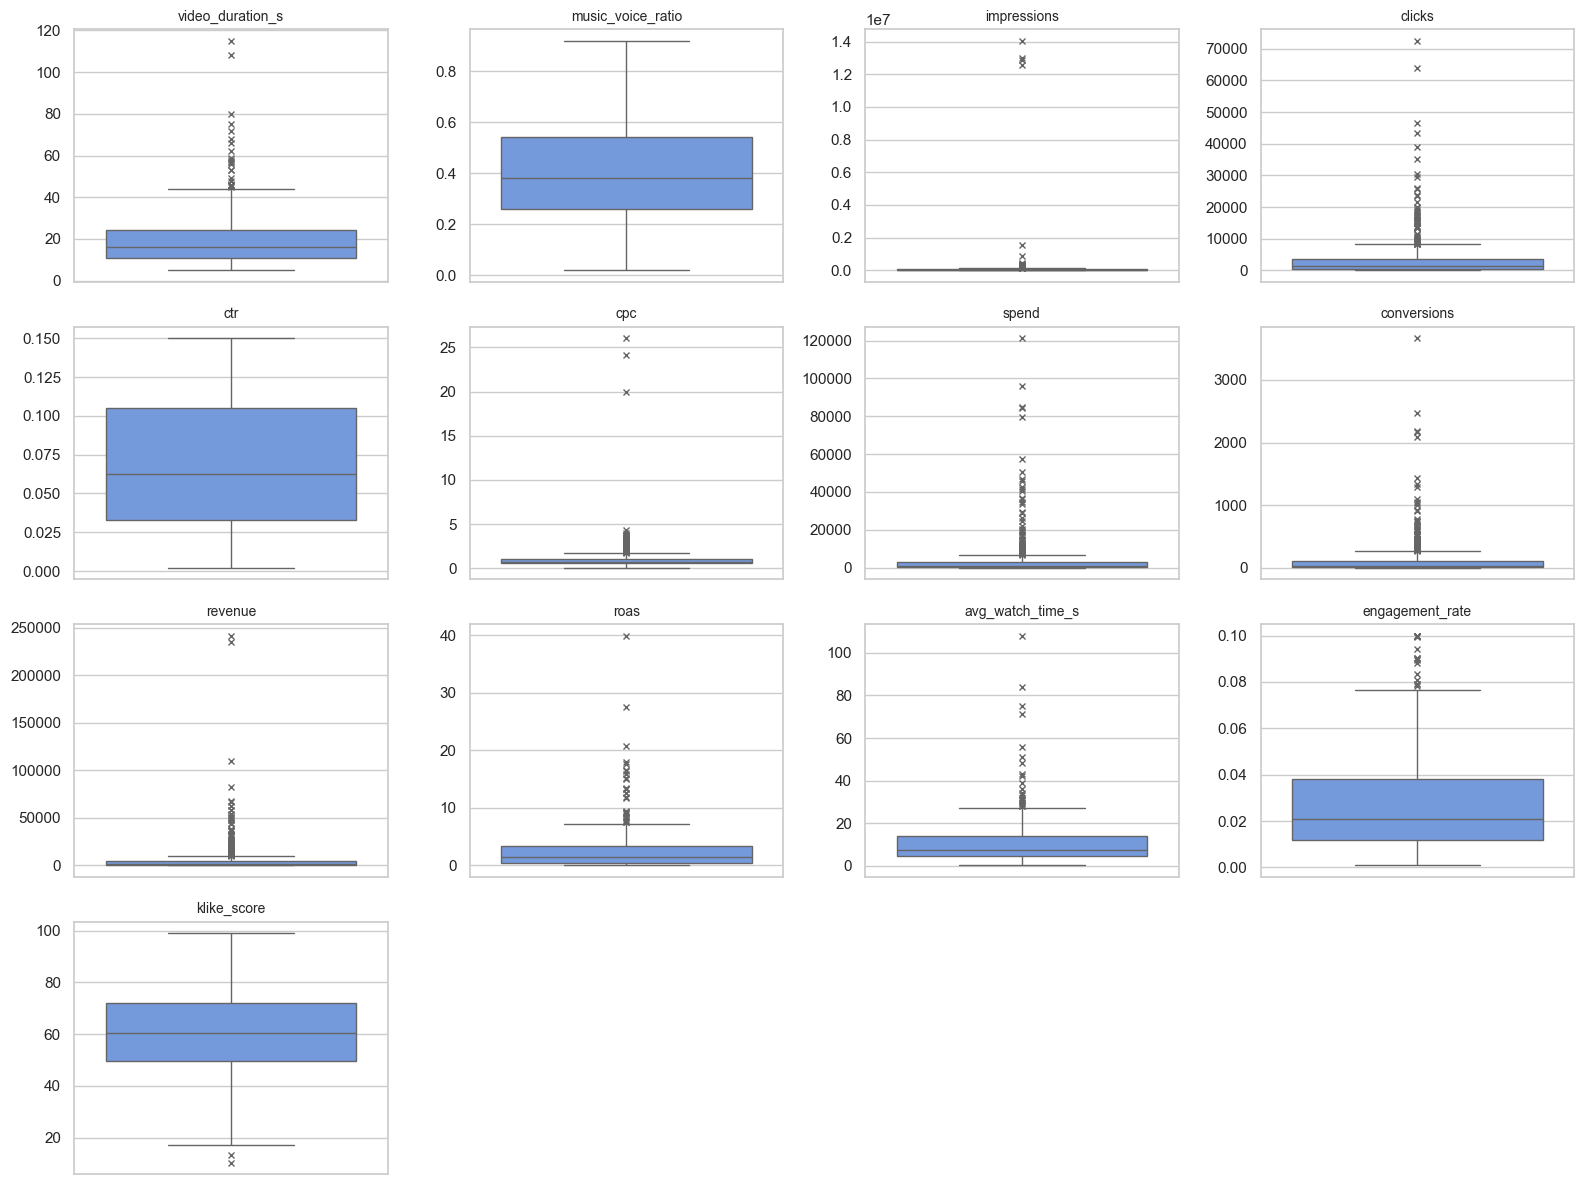

In [127]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 12))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 4, i)
    # O boxplot mostra a mediana, os quartis e os pontos isolados (outliers)
    sns.boxplot(y=df[col], color='cornflowerblue', flierprops={"marker": "x", "markerfacecolor": "red", "markersize": 5})
    plt.title(col, fontsize=10)
    plt.ylabel('')

plt.tight_layout()
plt.show()

In [128]:
df.head()

,platform,category,objective,target_audience_age,is_retargeting,video_duration_s,format,has_subtitle,has_cta,has_hook,has_face,text_density,music_voice_ratio,impressions,clicks,ctr,cpc,spend,conversions,revenue,roas,avg_watch_time_s,engagement_rate,klike_score,month,day_of_week,is_weekend
KLK-0001,Meta,Branding,awareness,18-24,False,16.0,vertical,True,True,False,True,medium,0.39,150825,5882,0.0390,0.82,4823.24,48,0.00,0.00,3.9,0.0446,63.6,1,0,0
KLK-0002,LinkedIn,App Install,traffic,25-34,False,24.5,horizontal,True,True,True,True,low,0.07,7433,493,0.0664,3.54,1745.22,34,279.24,0.16,6.4,0.0217,70.0,3,4,0
KLK-0003,TikTok,SaaS,traffic,25-34,False,8.0,vertical,True,True,True,True,medium,0.43,193198,15069,0.0780,0.38,5726.22,492,51053.44,8.92,8.0,0.1000,99.1,5,5,1
KLK-0004,TikTok,Lead Gen,engagement,25-34,False,27.0,quadrado,False,True,True,True,medium,0.54,6506,601,0.0925,0.71,426.71,19,1113.78,2.61,20.3,0.0414,74.9,12,4,0
KLK-0005,Meta,Branding,engagement,25-34,False,34.0,vertical,True,True,True,True,low,0.35,63830,2355,0.0369,0.38,894.90,13,0.00,0.00,34.0,0.0184,77.9,7,2,0


In [129]:
df.dtypes

platform                   str
category                   str
objective                  str
target_audience_age        str
is_retargeting            bool
video_duration_s       float64
format                     str
has_subtitle            object
has_cta                   bool
has_hook                  bool
has_face                  bool
text_density               str
music_voice_ratio      float64
impressions              int64
clicks                   int64
ctr                    float64
cpc                    float64
spend                  float64
conversions              int64
revenue                float64
roas                   float64
avg_watch_time_s       float64
engagement_rate        float64
klike_score            float64
month                    int32
day_of_week              int32
is_weekend               int64
dtype: object

In [130]:
df.columns

Index(['platform', 'category', 'objective', 'target_audience_age',
       'is_retargeting', 'video_duration_s', 'format', 'has_subtitle',
       'has_cta', 'has_hook', 'has_face', 'text_density', 'music_voice_ratio',
       'impressions', 'clicks', 'ctr', 'cpc', 'spend', 'conversions',
       'revenue', 'roas', 'avg_watch_time_s', 'engagement_rate', 'klike_score',
       'month', 'day_of_week', 'is_weekend'],
      dtype='str')

### Análise Bivariada: Atributos do Criativo vs Performance

A segunda pergunta do nosso desafio busca entender **quais características do vídeo mais impulsionam o sucesso da campanha**. Para responder a isso, dividiremos a análise em duas frentes:
1. **Matriz de Correlação (Heatmap):** Para cruzar variáveis numéricas contínuas (como duração e proporção de música) com os KPIs de marketing.
2. **Análise de Variáveis Booleanas (Sim/Não):** Para testar hipóteses estruturais do vídeo, como a presença de rosto humano (`has_face`), legendas (`has_subtitle`), e ganchos nos primeiros 3 segundos (`has_hook`).

In [131]:
cols_correlacao = [
    'video_duration_s', 'music_voice_ratio', 'text_density', 
    'ctr', 'roas', 'conversions', 'engagement_rate', 'klike_score'
]

In [132]:
df_temp_corr = df.copy()

In [133]:
df_temp_corr['text_density'] = df_temp_corr['text_density'].replace({
    'low': 0, 
    'medium': 1, 
    'high': 2
})


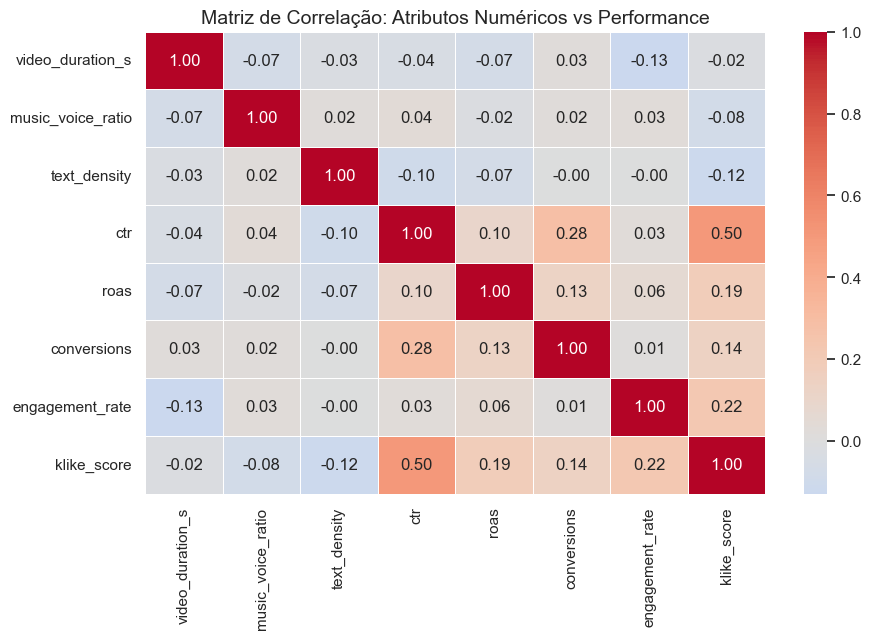

In [134]:
df_temp_corr[cols_correlacao] = df_temp_corr[cols_correlacao].apply(pd.to_numeric, errors='coerce')

corr_matrix = df_temp_corr[cols_correlacao].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Matriz de Correlação: Atributos Numéricos vs Performance", fontsize=14)
plt.show()

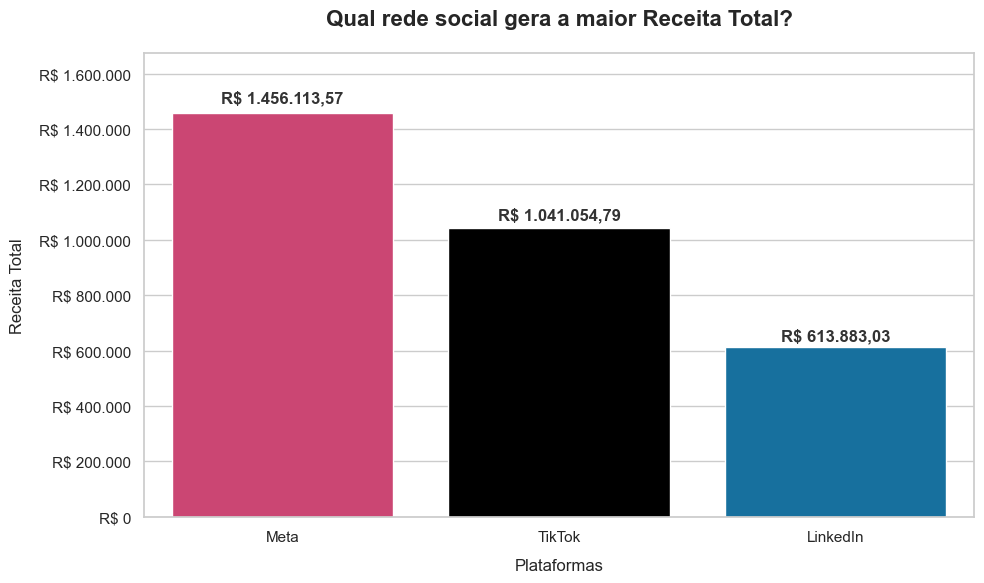

In [135]:

# 1. Agrupando receita por plataforma
df_renda_plataforma = df.groupby('platform')['revenue'].sum().reset_index()

# 2. Ordenando do maior para o menor (fundamental para a clareza visual)
df_renda_plataforma = df_renda_plataforma.sort_values(by='revenue', ascending=False)

# 3. Definindo paleta de cores customizada com as cores oficiais das marcas
cores_plataformas = {
    'Meta': '#E1306C',           # Rosa/Magenta Instagram (Meta inclui Instagram)
    'TikTok': '#000000',         # Preto TikTok
    'LinkedIn': '#0077B5'        # Azul LinkedIn
}

# 4. Configurando o estilo visual (adicionado whitegrid para melhor visualização da escala)
sns.set_theme(style="whitegrid")  
plt.figure(figsize=(10, 6)) # Ajuste leve na altura

# 5. Criando o gráfico de barras verticais (invertemos eixo X e Y)
ax = sns.barplot(
    data=df_renda_plataforma, 
    x='platform', 
    y='revenue',
    hue='platform',
    palette=cores_plataformas,
    legend=False # Ocultando a legenda pois o eixo X já tem os nomes
)

# 6. Adicionando Títulos e formatando os Eixos
plt.title('Qual rede social gera a maior Receita Total?', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Plataformas', fontsize=12, labelpad=10)  
plt.ylabel('Receita Total', fontsize=12, labelpad=10)

# Criando a formatação do eixo Y (escala de valores para ficar em Reais)
def formatar_moeda(x, pos):
    return f'R$ {x:,.0f}'.replace(',', 'X').replace('.', ',').replace('X', '.')

ax.yaxis.set_major_formatter(ticker.FuncFormatter(formatar_moeda))

# 7. Colocando os valores (R$) direto no topo das barras
for p in ax.patches:
    height = p.get_height()
    
    # Prevenção caso haja barras zeradas
    if pd.isna(height) or height == 0: continue
        
    # Formatação elegante de moeda para o padrão brasileiro
    texto_valor = f'R$ {height:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')
    
    # Texto fixado no topo da barra
    ax.text(
        p.get_x() + p.get_width() / 2.,  # x: centro da barra
        height + (height * 0.02),        # y: levemente acima da barra
        texto_valor,
        ha='center',                     # alinhamento horizontal
        va='bottom',                     # alinhamento vertical
        fontsize=12,
        fontweight='bold',
        color='#333333'
    )

# Aumentando o limite superior para não cortar os rótulos de texto
plt.ylim(0, df_renda_plataforma['revenue'].max() * 1.15)

plt.tight_layout()
plt.show()

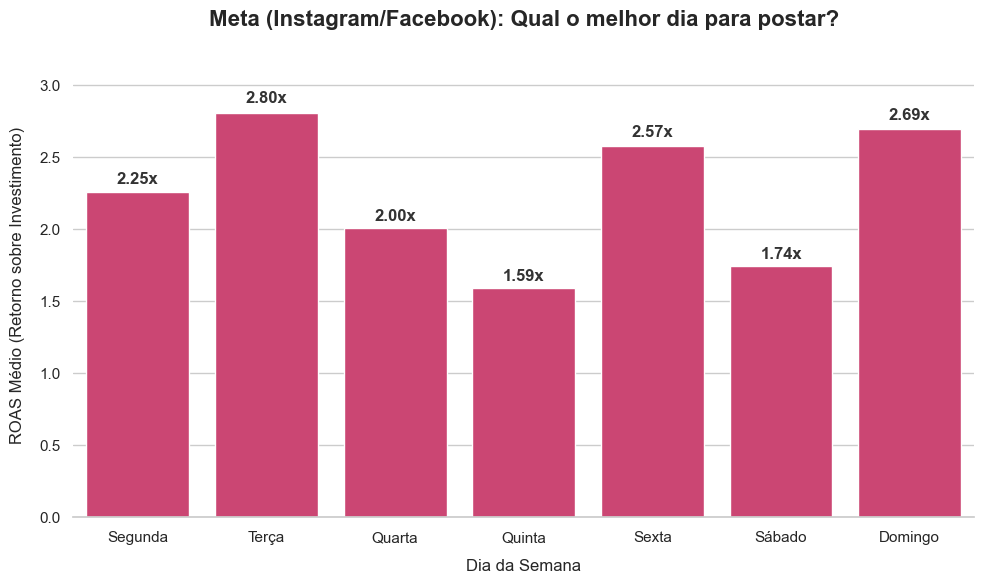

In [136]:

# 1. Filtrando apenas os dados do Meta
df_meta = df[df['platform'] == 'Meta'].copy()

# 2. Agrupando por dia da semana e calculando o ROAS médio
df_dias_meta = df_meta.groupby('day_of_week')['roas'].mean().reset_index()

# 3. Mapeando os números (0 a 6) para os nomes dos dias da semana em Português
mapa_dias = {
    0: 'Segunda', 1: 'Terça', 2: 'Quarta', 
    3: 'Quinta', 4: 'Sexta', 5: 'Sábado', 6: 'Domingo'
}
df_dias_meta['nome_dia'] = df_dias_meta['day_of_week'].map(mapa_dias)

# 4. Configurando o estilo visual (Padrão Executivo)
sns.set_theme(style="whitegrid")  
plt.figure(figsize=(10, 6))

# 5. Criando o gráfico de barras
# Usaremos a cor oficial do Meta que você definiu (#E1306C) para todas as barras
ax = sns.barplot(
    data=df_dias_meta, 
    x='nome_dia', 
    y='roas',
    color='#E1306C' 
)

# 6. Adicionando Títulos e formatando os Eixos
plt.title('Meta (Instagram/Facebook): Qual o melhor dia para postar?', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Dia da Semana', fontsize=12, labelpad=10)  
plt.ylabel('ROAS Médio (Retorno sobre Investimento)', fontsize=12, labelpad=10)

# 7. Colocando os valores direto no topo das barras
for p in ax.patches:
    height = p.get_height()
    
    if pd.isna(height) or height == 0: 
        continue
        
    # Formatando para mostrar com "x" indicando o multiplicador do retorno (ex: 2.50x)
    texto_valor = f'{height:,.2f}x'
    
    ax.text(
        p.get_x() + p.get_width() / 2.,  
        height + (height * 0.02),        
        texto_valor,
        ha='center',                     
        va='bottom',                     
        fontsize=12,
        fontweight='bold',
        color='#333333'
    )

# Aumentando o limite superior para não cortar os rótulos de texto
plt.ylim(0, df_dias_meta['roas'].max() * 1.15)

# Removendo bordas desnecessárias
sns.despine(left=True)

plt.tight_layout()
plt.show()

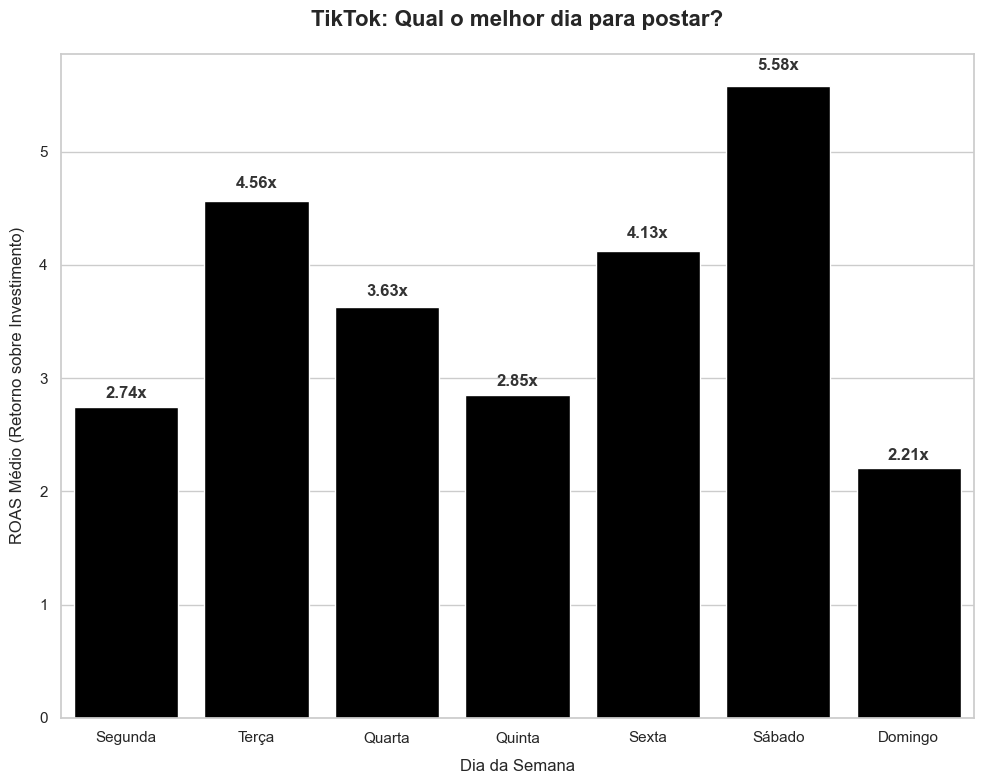

In [137]:
df_tiktok = df[df['platform'] == 'TikTok'].copy()

# 2. Agrupando por dia da semana e calculando o ROAS médio
df_dias_tiktok = df_tiktok.groupby('day_of_week')['roas'].mean().reset_index()

df_dias_tiktok['nome_dia'] = df_dias_tiktok['day_of_week'].map(mapa_dias)

# 4. Configurando o estilo visual (Padrão Executivo)
sns.set_theme(style="whitegrid")  
plt.figure(figsize=(10, 8))

# 5. Criando o gráfico de barras
# Usaremos a cor oficial do Meta que você definiu (#E1306C) para todas as barras
ax = sns.barplot(
    data=df_dias_tiktok, 
    x='nome_dia', 
    y='roas',
    color='#000000' 
)

# 6. Adicionando Títulos e formatando os Eixos
plt.title('TikTok: Qual o melhor dia para postar?', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Dia da Semana', fontsize=12, labelpad=10)  
plt.ylabel('ROAS Médio (Retorno sobre Investimento)', fontsize=12, labelpad=10)

# 7. Colocando os valores direto no topo das barras
for p in ax.patches:
    height = p.get_height()
    
    if pd.isna(height) or height == 0: 
        continue
        
    # Formatando para mostrar com "x" indicando o multiplicador do retorno (ex: 2.50x)
    texto_valor = f'{height:,.2f}x'
    
    ax.text(
        p.get_x() + p.get_width() / 2.,  
        height + (height * 0.02),        
        texto_valor,
        ha='center',                     
        va='bottom',                     
        fontsize=12,
        fontweight='bold',
        color='#333333'
    )


plt.tight_layout()
plt.show()

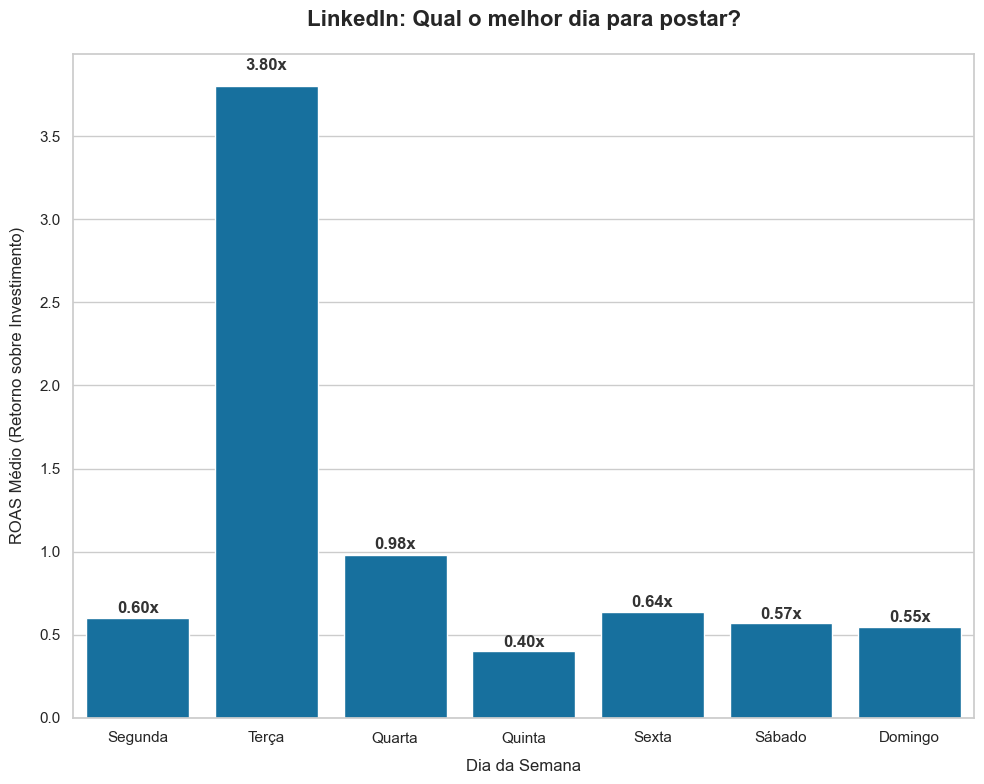

In [138]:
df_tiktok = df[df['platform'] == 'LinkedIn'].copy()

# 2. Agrupando por dia da semana e calculando o ROAS médio
df_dias_tiktok = df_tiktok.groupby('day_of_week')['roas'].mean().reset_index()

df_dias_tiktok['nome_dia'] = df_dias_tiktok['day_of_week'].map(mapa_dias)

# 4. Configurando o estilo visual (Padrão Executivo)
sns.set_theme(style="whitegrid")  
plt.figure(figsize=(10, 8))

# 5. Criando o gráfico de barras
# Usaremos a cor oficial do Meta que você definiu (#E1306C) para todas as barras
ax = sns.barplot(
    data=df_dias_tiktok, 
    x='nome_dia', 
    y='roas',
    color='#0077B5' 
)

# 6. Adicionando Títulos e formatando os Eixos
plt.title('LinkedIn: Qual o melhor dia para postar?', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Dia da Semana', fontsize=12, labelpad=10)  
plt.ylabel('ROAS Médio (Retorno sobre Investimento)', fontsize=12, labelpad=10)

# 7. Colocando os valores direto no topo das barras
for p in ax.patches:
    height = p.get_height()
    
    if pd.isna(height) or height == 0: 
        continue
        
    # Formatando para mostrar com "x" indicando o multiplicador do retorno (ex: 2.50x)
    texto_valor = f'{height:,.2f}x'
    
    ax.text(
        p.get_x() + p.get_width() / 2.,  
        height + (height * 0.02),        
        texto_valor,
        ha='center',                     
        va='bottom',                     
        fontsize=12,
        fontweight='bold',
        color='#333333'
    )


plt.tight_layout()
plt.show()